#ANTECEDENTES

Primero instalamos la libreria RDKit

In [1]:
import sys
import numpy as np

print("Python:", sys.version)
print("NumPy:", np.__version__)


Python: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
NumPy: 2.1.3


In [2]:
import scipy
import sklearn

print("SciPy:", scipy.__version__)
print("Scikit-learn:", sklearn.__version__)

print("NUMPY + SCIPY + SKLEARN OK")

SciPy: 1.16.3
Scikit-learn: 1.6.1
NUMPY + SCIPY + SKLEARN OK


# Librerias

In [4]:
from IPython.utils import io
import tqdm.notebook
import os, os.path, sys, random, subprocess
total = 100
with tqdm.notebook.tqdm(total=total) as pbar:
    with io.capture_output() as captured:
      pbar.update(0)
      import pandas as pd
      import numpy as np
      import seaborn as sn
      pbar.update(33)
      !pip install molplotly
      !pip install rdkit
      !pip install mordredcommunity #__________________
      pbar.update(66)
      #---------------------- RDKit packages
      from rdkit.Chem import AllChem
      from rdkit.Chem import rdMolDescriptors
      from rdkit.Chem.Draw import IPythonConsole
      from rdkit.Chem import Draw
      from rdkit import DataStructs
      from rdkit.ML.Cluster import Butina
      from rdkit.Chem import PandasTools

      from rdkit import Chem
      from rdkit.Chem import rdFMCS
      from rdkit.ML.Descriptors import MoleculeDescriptors
      from mordred import Calculator, descriptors
      from rdkit.Chem import Descriptors
      #---------------------- plotly packages
      import plotly.express as px
      import molplotly
      #from tqdm import tqdm.notebook
      #------------------- hide warning
      # import warnings
      # warnings.filterwarnings('ignore')
      pbar.update(100)

  0%|          | 0/100 [00:00<?, ?it/s]

#Funciones

In [5]:
#función de Culsterificación
def TaylorButina_Cluster(fpts, distThresh = 0.5):
    # generate distance matrix:
    dist_matrix = []
    nfpts = len(fpts)
    for i in tqdm.notebook.tqdm(range(1,nfpts)):

        # generate Tanimoto similary
        Tanimoto_coefficients = DataStructs.BulkTanimotoSimilarity(fpts[i],fpts[:i])
        dist_matrix.extend([1 - j for j in Tanimoto_coefficients])

    # cluster the Tanimoto scores using Butina:
    clusters = Butina.ClusterData(dist_matrix, nfpts, distThresh, isDistData=True)
    cluster_id_list = [0] * nfpts
    for idx,cluster in enumerate(clusters,1):
        for member in cluster:
            cluster_id_list[member] = idx
    return cluster_id_list

In [6]:
def RDkit_descriptors(smiles):
  mols = [Chem.MolFromSmiles(i) for i in smiles]
  # Use rdkit.Chem.Descriptors instead of the undefined 'Descriptors'
  calc = MoleculeDescriptors.MolecularDescriptorCalculator([x[0] for x in Descriptors._descList])
  desc_names = calc.GetDescriptorNames()

  Mol_descriptors = []
  for mol in mols:
    ##add hydrogens to molecule
    mol=Chem.AddHs(mol)
    ###Calculate all 200 descriptors for each molecule
    descriptors = calc.CalcDescriptors(mol)
    Mol_descriptors.append(descriptors)
  return Mol_descriptors, desc_names

In [7]:
def find_mcs_multiple(smiles_list):
    mols = [Chem.MolFromSmiles(smiles) for smiles in filtered_df.SMILES]

    # Check for invalid SMILES
    if any(mol is None for mol in mols):
        print("Invalid SMILES string provided in the list.")
        return None, None, 0, False

    mcs = rdFMCS.FindMCS(mols)
    mcs_mol = Chem.MolFromSmarts(mcs.smartsString)

    return mcs_mol, mcs.smartsString, mcs.numAtoms, True

In [8]:
def draw_multiple_mcs(smiles_list):
    mols = [Chem.MolFromSmiles(smiles) for smiles in filtered_df.SMILES]
    mcs_mol, mcs_smarts, mcs_atom_count, success = find_mcs_multiple(filtered_df.SMILES)
    if success:
        highlight_lists = [mol.GetSubstructMatch(mcs_mol) for mol in mols]

        # Get pIC50 values from the original df using indices from filtered_df
        pic50_values = [filtered_df.loc[idx, 'Activity'] for idx in filtered_df.index]

        mols.append(mcs_mol)  # Add MCS to list for drawing
        highlight_lists.append([]) # No highlight for MCS itself

        # Create legends with pIC50 values
        legends = [f"pIC50: {pic50:.2f}, cluster: {cluster_number} " for pic50 in pic50_values]
        legends.append(f"MCS cluster: {cluster_number}") # Legend for MCS

        img = Draw.MolsToGridImage(mols,
                                   legends=legends,
                                   highlightAtomLists=highlight_lists,
                                   subImgSize=(450,450))
        return img
    else:
        return None

In [9]:
#regresa el MCS entre dos moléculas
def find_mcs_and_draw(mol1, mol2):
    mcs = rdFMCS.FindMCS([mol1, mol2])
    mcs_mol = Chem.MolFromSmarts(mcs.smartsString)
    if mcs_mol:
        # generacion de la imagen
        img = Draw.MolsToGridImage([mol1, mol2, mcs_mol],
                                    #legends=['m', 'a', 'MCS'],
                                   legends=[#'Cluster ID: ' + str(x) +
                                            ', pIC50: ' + str(y) +
                                            ', index: '+ str(z)
                                            for y, z in zip(#dataset.Cluster_number,
                                                               dataset.Activity,
                                                               dataset.Cmpd)],

                                    highlightAtomLists=[
                                        mol1.GetSubstructMatch(mcs_mol),
                                        mol2.GetSubstructMatch(mcs_mol),
                                        [] # No highlighting for the MCS itself
                                    ])
        return img
    else:
        return None

In [10]:
#Hacemos una pequeña mpdificación
def find_mcs_and_draw_2(mol1, mol2):

    mcs = rdFMCS.FindMCS([mol1, mol2])
    mcs_mol = Chem.MolFromSmarts(mcs.smartsString)
    if mcs_mol:
        # generacion de la imagen
        # highlight_lists should have the same number of elements as the molecule list
        highlight_lists = [mol1.GetSubstructMatch(mcs_mol), mol2.GetSubstructMatch(mcs_mol), []] # Added empty list for mcs_mol
        img = Draw.MolsToGridImage([mol1, mol2, mcs_mol],
                                   highlightAtomLists=highlight_lists,
                                   subImgSize=(450,450),
                                   #weight= 350,
                                   # Using the corrected highlight_lists
                                    )
        return img
    else:
        return None

#Cargamos datos

In [11]:
# Base de Datos
!gdown --id 1j75nnoi1a3PF94X2Srq8q9ftMkghZh6j #IMPORTANTE
df_y = pd.read_excel("New_pBACE1.xlsx")

# Descriptores
! gdown --id 1-kXD7CQ6pCBaBk_OkmXyvGyQrL8T69mS
data = pd.read_excel("Descriptores_pBACE1.xlsx")

/usr/local/lib/python3.13/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1j75nnoi1a3PF94X2Srq8q9ftMkghZh6j
To: /content/New_pBACE1.xlsx
100% 30.1k/30.1k [00:00<00:00, 29.7MB/s]
/usr/local/lib/python3.13/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1-kXD7CQ6pCBaBk_OkmXyvGyQrL8T69mS
To: /content/Descriptores_pBACE1.xlsx
100% 7.84M/7.84M [00:00<00:00, 45.6MB/s]


In [12]:
df_y_info = df_y[['Cmpd', 'SMILES', 'Activity']]

# Merge the descriptor data ('data') with the compound information from df_y
# This creates a new DataFrame 'DATA' with descriptors, SMILES, and Activity
DATA = pd.concat([data, df_y_info], axis=1)

# Add the 'G' column as per previous notebook logic for the 'data' part
DATA['G'] = 'data'

In [13]:
# # Datos del grupo de exploración
!gdown -- 1bYVASyHZRID5kDrD_npUZmyJFUgGSt1F
excel = pd.read_excel("FinalXPLOR.xlsx")

Downloading...
From: https://drive.google.com/uc?id=1bYVASyHZRID5kDrD_npUZmyJFUgGSt1F
To: /content/FinalXPLOR.xlsx
100% 5.75k/5.75k [00:00<00:00, 13.2MB/s]


In [14]:
print(DATA.shape)
print(excel.shape)
# DATA.tail(3)


(425, 1830)
(15, 6)


In [15]:
DATA = pd.concat([DATA, excel], ignore_index=True)

In [16]:
# Eliminar filas donde 'G' es igual a 'data'
data = DATA[DATA['G'] == 'data']

In [17]:
PandasTools.AddMoleculeColumnToFrame(data,'SMILES', 'Structure') # Compuestos con los que se puede construir el modelo QSAR

/usr/local/lib/python3.13/dist-packages/rdkit/Chem/PandasTools.py:399: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  frame[molCol] = frame[smilesCol].map(Chem.MolFromSmiles)


In [18]:
# Eliminar filas donde 'G' es distinto a 'data' (grupo de exploración)
dataset = DATA[DATA['G'] != 'data']

In [19]:
# Añadimos las moléculas a la columna
PandasTools.AddMoleculeColumnToFrame(dataset,'SMILES', 'Structure') # Grupo de exploración


/usr/local/lib/python3.13/dist-packages/rdkit/Chem/PandasTools.py:399: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  frame[molCol] = frame[smilesCol].map(Chem.MolFromSmiles)


In [20]:
dataset.shape

(15, 1833)

# Agrupación de Taylor-Butina

## Para grupo de exploración

In [21]:
with tqdm.notebook.tqdm(total=total) as pbar:
    with io.capture_output() as captured:
      pbar.update(0)
      all_Mfpts = [AllChem.GetMorganFingerprintAsBitVect(mol, 2, nBits=4096) for mol in dataset.Structure if mol is not None]
      pbar.update(100)

  0%|          | 0/100 [00:00<?, ?it/s]

In [22]:
cluster_id = TaylorButina_Cluster(all_Mfpts, distThresh=0.61)

  0%|          | 0/14 [00:00<?, ?it/s]

In [23]:
# Number of clusters
len(np.unique(cluster_id))

2

In [24]:
#creamos un nuevo dataframe donde agregaremos la información del cluster
dataset_cs = dataset[['Cmpd','SMILES','Structure', 'Activity', 'G']] # Selecciona algunas columnas y agrega una columna de número de cluster
dataset_cs['Cluster_number'] = cluster_id #Colocamos la identificación del clúster en el dataframe.
# Sort clusters
dataset_cs_sorted = dataset_cs.sort_values(["Cluster_number"])
# Reset index of dataset_cs_sorted
dataset_cs_sorted = dataset_cs_sorted.reset_index(drop=True)
dataset_cs_sorted.shape


/tmp/ipykernel_2260/1603166973.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset_cs['Cluster_number'] = cluster_id #Colocamos la identificación del clúster en el dataframe.


(15, 6)

In [25]:
# Get the frequency of each cluster number
cluster_counts = dataset_cs_sorted['Cluster_number'].value_counts()

# Filter out cluster numbers with a frequency less than 2
clusters_with_unique_values = cluster_counts[cluster_counts == 1].index

# Filter the dataset to include only the rows where the cluster number is in the valid clusters
clusters_with_unique_values_df = dataset_cs_sorted[dataset_cs_sorted['Cluster_number'].isin(clusters_with_unique_values)]
#clusters_with_unique_values_df

In [26]:
# prompt:  toma los valores de Cluster number donde este tenga una frecuencia de al menos 2

# Get the frequency of each cluster number
cluster_counts = dataset_cs_sorted['Cluster_number'].value_counts()

# Filter out cluster numbers with a frequency less than 2
valid_clusters = cluster_counts[cluster_counts >= 2].index

# Filter the dataset to include only the rows where the cluster number is in the valid clusters
valid_clusters_df = dataset_cs_sorted[dataset_cs_sorted['Cluster_number'].isin(valid_clusters)]

#valid_clusters_df

In [27]:
valid_clusters_df.shape

(14, 6)

In [28]:
idx = valid_clusters_df.groupby(['Cluster_number'])['Activity'].idxmax()# Group data by 'Cluster_number' and get the index of the row with the maximum 'Activity' in each group


In [29]:
result_df = dataset_cs_sorted.copy() #EVITA TOAR para cada uno de los Cluster_number el elemento que tenga el mayor valor en Activity
result_df.shape

(15, 6)

In [30]:
result_df = result_df.reset_index(drop=True)
result_df

,Cmpd,SMILES,Structure,Activity,G,Cluster_number
0,NaN,NC1=NC2=C(CCCC(N3C4CC(C3)NC4)=O)C=CC=C2C=C1C(C)C,<rdkit.Chem.rdchem.Mol object at 0x7a60a09fe2d0>,8.010023,xplor,1
1,NaN,NC1=NC2=C(CCCC(N3C4CC(C3)N(C)C4)=O)C=CC=C2C=C1...,<rdkit.Chem.rdchem.Mol object at 0x7a60a09fe340>,8.212045,xplor,1
2,NaN,NC1=NC2=C(CCCC(N3C4CC(C3)N(CC)C4)=O)C=CC=C2C=C...,<rdkit.Chem.rdchem.Mol object at 0x7a60a09fe3b0>,8.075046,xplor,1
3,NaN,NC1=NC2=C(CCCC(N3C4CC(C3)N(C(C)C)C4)=O)C=CC=C2...,<rdkit.Chem.rdchem.Mol object at 0x7a60a09fe420>,8.074524,xplor,1
4,NaN,NC1=NC2=C(CCCC(N3C4CC(C3)N(C)C4)=O)C=C(C(C)C)C...,<rdkit.Chem.rdchem.Mol object at 0x7a60a09fe490>,8.138916,xplor,1
5,NaN,NC1=NC2=C(CCCC(N3C4CC(C3)N(C)C4)=O)C=CC(C(C)C)...,<rdkit.Chem.rdchem.Mol object at 0x7a60a09fe500>,8.128249,xplor,1
6,NaN,NC1=NC2=C(CCCC(N3C4CC(C3)N(C)C4)=O)C=CC=C2C(C(...,<rdkit.Chem.rdchem.Mol object at 0x7a60a09fe570>,8.074977,xplor,1
7,NaN,NC1=NC2=C(CCCC(N3C4CC(C3)N(C)C4)=O)C=CC=C2C=C1...,<rdkit.Chem.rdchem.Mol object at 0x7a60a09fe5e0>,8.212045,xplor,1
8,NaN,NC1=NC2=C(C(C)C)C=CC=C2C=C1CCCC(N3C4CC(C3)N(C)...,<rdkit.Chem.rdchem.Mol object at 0x7a60a09fe650>,8.218014,xplor,1
9,NaN,NC1=NC2=C(C(C)C)C=CC=C2C(CCCC(N3C4CC(C3)N(C)C4...,<rdkit.Chem.rdchem.Mol object at 0x7a60a09fe6c0>,8.052100,xplor,1


## Para data (modelo QSAR)

In [31]:
data = data.drop_duplicates(subset=['SMILES'], keep='first')
# data.shape

In [32]:
with tqdm.notebook.tqdm(total=total) as pbar:
    with io.capture_output() as captured:
      pbar.update(0)
      all_Mfpts = [AllChem.GetMorganFingerprintAsBitVect(mol, 2, nBits=4096) for mol in data.Structure]
      pbar.update(100)

  0%|          | 0/100 [00:00<?, ?it/s]

In [33]:
cluster_id = TaylorButina_Cluster(all_Mfpts, distThresh=0.61)

  0%|          | 0/424 [00:00<?, ?it/s]

In [34]:
# Number of clusters
len(np.unique(cluster_id))

28

In [35]:
#creamos un nuevo dataframe donde agregaremos la información del cluster
data_cs = data[['Cmpd','SMILES','Structure', 'Activity', 'G']] # Selecciona algunas columnas y agrega una columna de número de cluster
data_cs['Cluster_number'] = cluster_id #Colocamos la identificación del clúster en el dataframe.
#data_cs #observar los primeros diez elementos del dataframe

/tmp/ipykernel_2260/4033040782.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_cs['Cluster_number'] = cluster_id #Colocamos la identificación del clúster en el dataframe.


In [36]:
# Sort clusters
data_cs_sorted = data_cs.sort_values(["Cluster_number"])

In [37]:
data_cs_sorted

,Cmpd,SMILES,Structure,Activity,G,Cluster_number
424,64j,O=C(NC1=CC=C(F)C([C@]2(C)CO[C@@](C)(C(F)(F)F)C...,<rdkit.Chem.rdchem.Mol object at 0x7a60a0947530>,8.096910,data,1
423,64i,O=C(NC1=CC=C(F)C([C@]2(C)CO[C@@](C)(C(F)(F)F)C...,<rdkit.Chem.rdchem.Mol object at 0x7a60a09474c0>,7.795880,data,1
422,64h,O=C(NC1=CC=C(F)C([C@]2(C)CO[C@@](C)(C(F)(F)F)C...,<rdkit.Chem.rdchem.Mol object at 0x7a60a0947450>,7.853872,data,1
421,64g,O=C(NC1=CC=C(F)C([C@]2(C)CO[C@@](C)(C(F)(F)F)C...,<rdkit.Chem.rdchem.Mol object at 0x7a60a09473e0>,7.481486,data,1
393,13,NC1=N[C@@](C2=CC(NC(C3=CC=C(C#N)C=N3)=O)=CC=C2...,<rdkit.Chem.rdchem.Mol object at 0x7a60a09467a0>,8.085657,data,1
...,...,...,...,...,...,...
226,Inhibidor-1,CCCN(S(=O)(C)=O)C1=CC(C(N[C@H](CN[C@@H](CCCCC)...,<rdkit.Chem.rdchem.Mol object at 0x7a609ed3cac0>,8.397940,data,24
204,35,CC#Cc1cncc(-c2ccc3c(c2)[C@@]2(N=C(C)C(N)=N2)[C...,<rdkit.Chem.rdchem.Mol object at 0x7a609ed3c120>,9.221849,data,25
200,28,S1C([C@]2(C)CC(=O)N(C)C(=N)N2)=C(Cl)C=C1C1C=C(...,<rdkit.Chem.rdchem.Mol object at 0x7a609ed3de00>,8.769551,data,26
185,6,C[C@]12CCCO[C@@H]1[C@]3(COC(=N3)N)C4=C(O2)C=CC...,<rdkit.Chem.rdchem.Mol object at 0x7a60a095fdf0>,7.346787,data,27


In [38]:
# prompt: reinicia los indices da dataset:cs_sorted

# Reset index of dataset_cs_sorted
data_cs_sorted = data_cs_sorted.reset_index(drop=True)
data_cs_sorted.shape

(425, 6)

In [39]:
# Esta es una combinación de result_df que es el dataset del grupo de exploración y data_cs que reperesenta a nuestos datos del modelo Kurt
combined_df = pd.concat([data_cs_sorted, result_df], ignore_index=True)
combined_df.shape

(440, 6)

# Filtrar moléculas por descripotres rdkit

In [40]:
# áalculo de descriptores RdKIT
Mol_descriptors, desc_names = RDkit_descriptors(combined_df['SMILES'])
df_with_200_descriptors = pd.DataFrame(Mol_descriptors, columns=desc_names)
# Concatenate the two dataframes along columns (axis=1)
final_df = pd.concat([combined_df, df_with_200_descriptors], axis=1)
len(list(final_df.columns))

223

In [41]:
str(list(final_df.columns))

"['Cmpd', 'SMILES', 'Structure', 'Activity', 'G', 'Cluster_number', 'MaxAbsEStateIndex', 'MaxEStateIndex', 'MinAbsEStateIndex', 'MinEStateIndex', 'qed', 'SPS', 'MolWt', 'HeavyAtomMolWt', 'ExactMolWt', 'NumValenceElectrons', 'NumRadicalElectrons', 'MaxPartialCharge', 'MinPartialCharge', 'MaxAbsPartialCharge', 'MinAbsPartialCharge', 'FpDensityMorgan1', 'FpDensityMorgan2', 'FpDensityMorgan3', 'BCUT2D_MWHI', 'BCUT2D_MWLOW', 'BCUT2D_CHGHI', 'BCUT2D_CHGLO', 'BCUT2D_LOGPHI', 'BCUT2D_LOGPLOW', 'BCUT2D_MRHI', 'BCUT2D_MRLOW', 'AvgIpc', 'BalabanJ', 'BertzCT', 'Chi0', 'Chi0n', 'Chi0v', 'Chi1', 'Chi1n', 'Chi1v', 'Chi2n', 'Chi2v', 'Chi3n', 'Chi3v', 'Chi4n', 'Chi4v', 'HallKierAlpha', 'Ipc', 'Kappa1', 'Kappa2', 'Kappa3', 'LabuteASA', 'PEOE_VSA1', 'PEOE_VSA10', 'PEOE_VSA11', 'PEOE_VSA12', 'PEOE_VSA13', 'PEOE_VSA14', 'PEOE_VSA2', 'PEOE_VSA3', 'PEOE_VSA4', 'PEOE_VSA5', 'PEOE_VSA6', 'PEOE_VSA7', 'PEOE_VSA8', 'PEOE_VSA9', 'SMR_VSA1', 'SMR_VSA10', 'SMR_VSA2', 'SMR_VSA3', 'SMR_VSA4', 'SMR_VSA5', 'SMR_VSA6', 

In [42]:
# Activity vs descriptors
fig = px.scatter(final_df,# x='MinPartialCharge',
                 x = 'NumHeterocycles',
                 y='Activity', #hover_data=['Activity', 'Cluster_number'],
                  width=1250, height= 500,
                 color='G')

app = molplotly.add_molecules(fig=fig, df=final_df,
                              smiles_col="SMILES",

                              #symbol_col='Cluster_number',
                              color_col='G',
                               caption_cols=['NumHeteroatoms', 'NumHeterocycles', 'NumRotatableBonds',],
                              #caption_cols=["y_pred", "y_true", "Molecular Weight"],
                              #show_coords=False,
                              #title_col = 'Cluster_number'
                              )
app.run(mode="inline", port=8777)

/usr/local/lib/python3.13/dist-packages/jupyter_dash/jupyter_app.py:103: UserWarning:

JupyterDash is deprecated, use Dash instead.
See https://dash.plotly.com/dash-in-jupyter for more details.



<IPython.core.display.Javascript object>

In [43]:
#filtramos los datos por PC
filtered_dataset1 = final_df.copy()
# filtered_dataset1 = filtered_dataset1[filtered_dataset1['FpDensityMorgan2'] > 1.7]
#filtered_dataset1 = filtered_dataset1[filtered_dataset1['BCUT2D_CHGHI'] < 2.4]
#filtered_dataset1 = filtered_dataset1[filtered_dataset1['AvgIpc'] >= 2.8]
#filtered_dataset1 = filtered_dataset1[filtered_dataset1['BalabanJ'] <= 2.9]
#filtered_dataset1 = filtered_dataset1[filtered_dataset1['BalabanJ'] >= 1.4]
#filtered_dataset1 = filtered_dataset1[filtered_dataset1['PEOE_VSA1'] <= 21]
# filtered_dataset1 = filtered_dataset1[filtered_dataset1['PEOE_VSA10'] <= 24]
# filtered_dataset1 = filtered_dataset1[filtered_dataset1['PEOE_VSA13'] <= 12]
#filtered_dataset1 = filtered_dataset1[filtered_dataset1['NumAtomStereoCenters'] <= 1]#'NumHeterocycles'
#filtered_dataset1 = filtered_dataset1[filtered_dataset1['NumHeterocycles'] != 0]
#filtered_dataset1 = filtered_dataset1[filtered_dataset1['NumHeterocycles'] < 5]
# filtered_dataset1.shape

# Comparación de propiedades

In [44]:
fig = px.scatter(filtered_dataset1, x='MaxAbsPartialCharge', y= 'Activity',
                 color='G',
                 color_continuous_scale='portland_r',
                 height=550, width = 700)

app = molplotly.add_molecules(fig=fig, df=filtered_dataset1,
                              smiles_col="SMILES",
                              #symbol_col='Cluster_number',
                              color_col='G',
                              caption_cols=['Activity', 'Cluster_number', 'G', 'Cmpd'],
                              #show_coords=False,
                              title_col = 'Cluster_number',
                              width = 350)

app.run(mode="inline", port=8770)

/usr/local/lib/python3.13/dist-packages/jupyter_dash/jupyter_app.py:103: UserWarning:

JupyterDash is deprecated, use Dash instead.
See https://dash.plotly.com/dash-in-jupyter for more details.



<IPython.core.display.Javascript object>

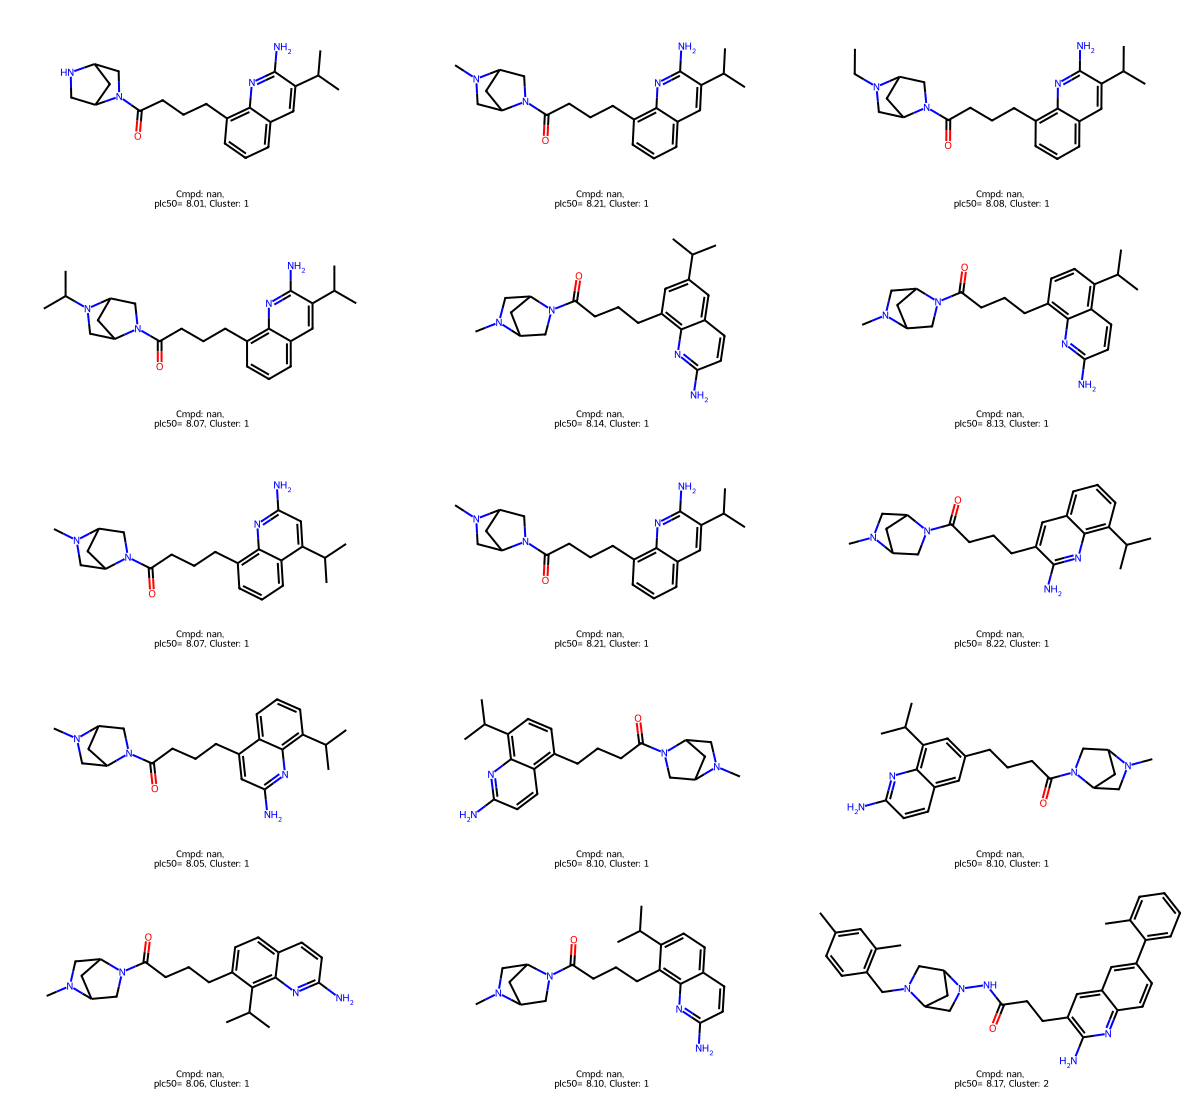

In [45]:
# Visualizamos las moléculas del grupo de exploración
filtered_dataset2 = filtered_dataset1[filtered_dataset1['G'] != 'data']
Draw.MolsToGridImage([x for x in filtered_dataset2["Structure"]],#0:16],
                     maxMols=100,
                     legends=[f'Cmpd: {x},\n pIc50= {y:.2f}, Cluster: {z}' for x,y,z in zip(filtered_dataset2["Cmpd"],
                                                                                                 filtered_dataset2["Activity"],
                                                                                                 filtered_dataset2["Cluster_number"])],
                     subImgSize=(400,220), molsPerRow=3)

# Cluster de grupo de exploración

In [46]:
dataset_final = filtered_dataset2.copy()
# Ordena los elementos de dataset_final de acuerdo a Cluster_number
dataset_final_sorted = dataset_final.sort_values(by='Cluster_number')
#dataset_final_sorted

In [47]:
# Obtenga números de clúster únicos donde el número de estructuras sea = 1
clusters = dataset_final.groupby('Cluster_number')['Structure'].count().reset_index()
clusters = clusters[clusters['Structure'] == 1]['Cluster_number'].tolist()

In [48]:
# Obtenga números de clúster únicos donde el número de estructuras sea >= 2
clusters_to_process = dataset_final.groupby('Cluster_number')['Structure'].count().reset_index()
clusters_to_process = clusters_to_process[clusters_to_process['Structure'] >= 2]['Cluster_number'].tolist()

In [49]:
clusters_to_process

[1]

In [50]:
mcs_results = {}  # Store MCS results for each cluster

for cluster_number in clusters_to_process:
    filtered_df = dataset_final[dataset_final['Cluster_number'] == cluster_number]
    mcs_mol, _, _, success = find_mcs_multiple(filtered_df.SMILES)
    if success:
        mcs_results[cluster_number] = (mcs_mol, len(filtered_df)) # Store MCS and molecule count
    else:
        mcs_results[cluster_number] = (None, len(filtered_df)) # Store None and molecule count if MCS not found
        print(f"Could not find MCS for cluster {cluster_number}")

In [51]:
mcs_results

{1: (<rdkit.Chem.rdchem.Mol at 0x7a609fd7e8f0>, 14)}

In [52]:
filtered_df = dataset_final[dataset_final['Cluster_number'].isin(clusters_to_process)]
#filtered_df
# prompt: con mcs_results has un dataframe donde tengas el objeto mol relacionado con sus cluster_number
mcs_results_df = pd.DataFrame(list(mcs_results.items()), columns=['Cluster_number', 'mol'])
mcs_results_df

,Cluster_number,mol
0,1,(<rdkit.Chem.rdchem.Mol object at 0x7a609fd7e8...


In [53]:
mcs_results_df = pd.DataFrame(list(mcs_results.items()), columns=['Cluster_number', 'mol_count'])

In [54]:
# De dataset_cs toma los valores donde cluster_nuiber solo aparece una vez
cluster_counts = dataset_final['Cluster_number'].value_counts()
single_occurrence_clusters = cluster_counts[cluster_counts == 1].index
dataset_cs_filtered = dataset_cs[dataset_cs['Cluster_number'].isin(single_occurrence_clusters)]

In [55]:
# prompt: ordena  de manera crecienta con respecto a la columna Cluster_nummber a dataset_cs_filtered
dataset_cs_filtered = dataset_cs_filtered.sort_values('Cluster_number')
#dataset_cs_filtered

In [56]:
mcs_results

{1: (<rdkit.Chem.rdchem.Mol at 0x7a609fd7e8f0>, 14)}

In [57]:
# Create a single list for legends
legends = []

# Add legends for mcs_results_df
legends.extend(['Cluster ID: ' + str(x) +
                ', freq: ' + str(y) + '\n' +
                'PIC50 '+'\n'
                'max : ' + str(round(z,2)) + ', min : ' + str(round(w,2))
                for x, y, z, w in zip(mcs_results_df.Cluster_number,
                                      mcs_results_df.mol_count,
                                      dataset_final.groupby('Cluster_number')['Activity'].max(),
                                      dataset_final.groupby('Cluster_number')['Activity'].min())])

# Add legends for dataset_cs_filtered
legends.extend(['Cmpd: ' + str(x) + '\n'', pIC50: ' + str(round(y,2)) for x, y in zip(dataset_cs_filtered.Cmpd,
                                                                                dataset_cs_filtered.Activity)])

In [58]:
# Create a single list for legends
legends2 = []

# Add legends for mcs_results_df
legends2.extend(['Cluster ID: ' + str(x) +'\n'
                 'Cmpd: ' + str(y) + '\n'
                 'PMIC: '+ str(round(z,2))
                 for x, y,z in zip(filtered_df.Cluster_number,
                                   filtered_df.Cmpd,
                                   filtered_df.Activity)])

# Add legends for dataset_cs_filtered
legends2.extend(['Cmpd: ' + str(x) + '\n'
                 ', pMIC: ' + str(round(y,2))
                 for x, y in zip(dataset_cs_filtered.Cmpd,
                                 dataset_cs_filtered.Activity)])

#  Cuadrícula de´grupo de exploración con MCS de cada agrupación

In [59]:
# # @title
# # Combina a y b
# combined_image = Draw.MolsToGridImage(
#     mols=[mol for mol in mcs_results_df.mol][:] +
#          [x for x in dataset_cs_filtered["Structure"]][:], # Slice the list instead of indexing a single element
#     legends=legends,  # use the legends list created before
#     maxMols=200, subImgSize=(550, 450), molsPerRow=4)
# # Display the combined image
# combined_image

# Presentación de moléculas

In [60]:
# Reset the index and create a new 'indice' column with the new index values
filtered_dataset1.reset_index(drop=True, inplace=True)
filtered_dataset1['indice'] = filtered_dataset1.index

In [61]:
filtered_dataset1

,Cmpd,SMILES,Structure,Activity,G,Cluster_number,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,...,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea,indice
0,64j,O=C(NC1=CC=C(F)C([C@]2(C)CO[C@@](C)(C(F)(F)F)C...,<rdkit.Chem.rdchem.Mol object at 0x7a60a0947530>,8.096910,data,1,15.924845,15.924845,0.534260,-6.284272,...,0,0,0,0,0,0,0,0,0,0
1,64i,O=C(NC1=CC=C(F)C([C@]2(C)CO[C@@](C)(C(F)(F)F)C...,<rdkit.Chem.rdchem.Mol object at 0x7a60a09474c0>,7.795880,data,1,15.984336,15.984336,0.695255,-6.341244,...,0,0,0,0,0,0,0,0,0,1
2,64h,O=C(NC1=CC=C(F)C([C@]2(C)CO[C@@](C)(C(F)(F)F)C...,<rdkit.Chem.rdchem.Mol object at 0x7a60a0947450>,7.853872,data,1,16.087327,16.087327,0.830810,-6.381713,...,0,0,0,0,0,0,0,0,0,2
3,64g,O=C(NC1=CC=C(F)C([C@]2(C)CO[C@@](C)(C(F)(F)F)C...,<rdkit.Chem.rdchem.Mol object at 0x7a60a09473e0>,7.481486,data,1,16.117939,16.117939,0.756736,-6.360951,...,0,0,0,0,0,0,0,0,0,3
4,13,NC1=N[C@@](C2=CC(NC(C3=CC=C(C#N)C=N3)=O)=CC=C2...,<rdkit.Chem.rdchem.Mol object at 0x7a60a09467a0>,8.085657,data,1,16.098211,16.098211,0.084759,-3.971656,...,0,0,0,0,0,0,0,0,0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
435,NaN,NC1=NC2=C(C(C)C)C=CC(CCCC(N3C4CC(C3)N(C)C4)=O)...,<rdkit.Chem.rdchem.Mol object at 0x7a60a09fe730>,8.098273,xplor,1,14.187152,14.187152,0.471121,-4.745626,...,0,0,0,0,0,0,0,0,0,435
436,NaN,NC1=NC2=C(C(C)C)C=C(CCCC(N3C4CC(C3)N(C)C4)=O)C...,<rdkit.Chem.rdchem.Mol object at 0x7a60a09fe7a0>,8.101596,xplor,1,14.178958,14.178958,0.425656,-4.778527,...,0,0,0,0,0,0,0,0,0,436
437,NaN,NC1=NC2=C(C(C)C)C(CCCC(N3C4CC(C3)N(C)C4)=O)=CC...,<rdkit.Chem.rdchem.Mol object at 0x7a60a09fe810>,8.059777,xplor,1,14.245219,14.245219,0.471121,-4.842672,...,0,0,0,0,0,0,0,0,0,437
438,NaN,NC1=NC2=C(CCCC(N3C4CC(C3)N(C)C4)=O)C(C(C)C)=CC...,<rdkit.Chem.rdchem.Mol object at 0x7a60a09fe880>,8.102355,xplor,1,14.301432,14.301432,0.490748,-4.856494,...,0,0,0,0,0,0,0,0,0,438


In [62]:
# # @title
# img = Draw.MolsToGridImage([x for x in filtered_dataset1.Structure],
#                                   # legends=[f'Cmpd: {a}, \n pic50: {x:0.2f}, indice {y}' for a,x,y in
#                                   #          zip(filtered_dataset1.Cmpd,filtered_dataset1.Activity, filtered_dataset1.indice)],
#                           maxMols=500,
#                          #highlightAtomLists=highlight_lists
#                                #highlightAtomLists=highlight_lists,
#                            molsPerRow=6,
#                                    subImgSize=(450,450))
# img

# Matriz de similitud final (data vs xplor)

In [63]:
# @title
# prompt: para los smiles de dataset_cs_sorted calculca los indices de tanimoto de manera matricial
with tqdm.notebook.tqdm(total=total) as pbar:
    with io.capture_output() as captured:
      pbar.update(0)
      # Calculate fingerprints for the molecules in dataset_cs_sorted
      fps = [AllChem.GetMorganFingerprintAsBitVect(mol, 2, nBits=2048) for mol in filtered_dataset1["Structure"]]
      # Calculate the Tanimoto similarity matrix
      tanimoto_matrix = np.zeros((len(fps), len(fps)))
      for i in range(len(fps)):
        for j in range(i, len(fps)):
          # Calculate only upper triangle, it's symmetric
          tanimoto_matrix[i, j] = DataStructs.CosineSimilarity(fps[i], fps[j])
          #tanimoto_matrix[i, j] = DataStructs.TanimotoSimilarity(fps[i], fps[j])
          tanimoto_matrix[j, i] = tanimoto_matrix[i, j] # Fill the lower triangle
          # Assuming 'tanimoto_matrix' is already calculated as in your original code
      pbar.update(100)

  0%|          | 0/100 [00:00<?, ?it/s]

In [64]:
# @title
fig = px.imshow(tanimoto_matrix,
                labels=dict(x="índice de molécula", y="índice de molécula", color="Similitud de coseno"),
                title="Heatmap de la matriz de similitud de cosenos",
                color_continuous_scale='Blues', # You can change the color scale
                width=1000, height=800)
Xplor_Begining = 424
fig.update_xaxes(side="bottom")  # Move x-axis label to the bottom
fig.add_shape(type="line", x0=Xplor_Begining, y0=0, x1=Xplor_Begining, y1=len(tanimoto_matrix), line=dict(color="Green", width=2, dash="dashdot"))
fig.add_shape(type="line", x0=0, y0=Xplor_Begining, x1=len(tanimoto_matrix), y1=Xplor_Begining, line=dict(color="Green", width=2, dash="dashdot"))
fig.show()

Output hidden; open in https://colab.research.google.com to view.

Análisis de la matriz

cluster ID: 10
pIC50: 7.795880017
G: data
Cmpd: 58c


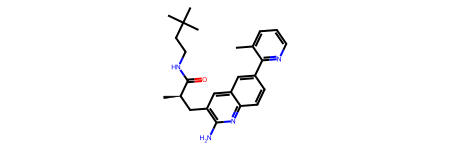

In [65]:
idx= 324 #495 #485 #435 #493
print('cluster ID: '+ str(filtered_dataset1["Cluster_number"][idx]))
print('pIC50: ' + str(filtered_dataset1["Activity"][idx]))
print('G: '+ str(filtered_dataset1["G"][idx]))
print('Cmpd: '+ str(filtered_dataset1["Cmpd"][idx]))
m1 = filtered_dataset1["Structure"][idx]
m1

sub_idx: 433
cluster ID: 1
pIC50: 8.218013571781258
G: xplor
Cmpd: nan


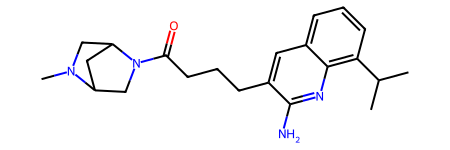

In [66]:
idx = 433#494
print ('sub_idx: '+ str(idx))
print('cluster ID: '+ str(filtered_dataset1["Cluster_number"][idx]))
print('pIC50: ' + str(filtered_dataset1["Activity"][idx]))
print('G: '+ str(filtered_dataset1["G"][idx]))
print('Cmpd: '+ str(filtered_dataset1["Cmpd"][idx]))
m2 = filtered_dataset1["Structure"][idx]
m2

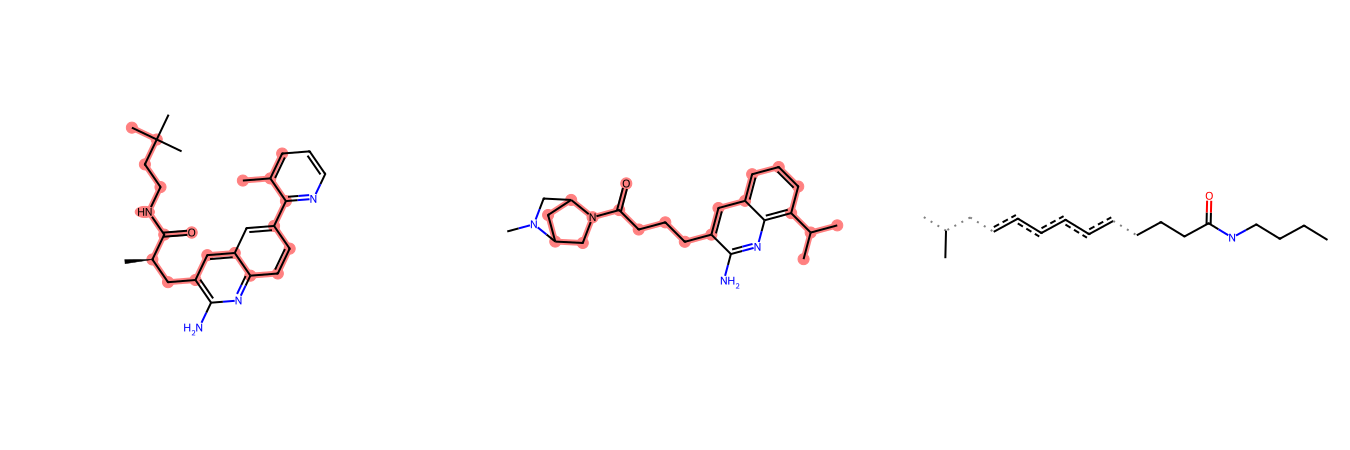

In [67]:
comparison_image_ = find_mcs_and_draw_2(m1, m2)
comparison_image_

In [68]:
idx = 433
# Extract Tanimoto similarities for compound 10
compound_idx_similarities = tanimoto_matrix[idx]

# Create a DataFrame for plotting
similarity_df = pd.DataFrame({'Compound': range(len(compound_idx_similarities)),'Tanimoto Similarity': compound_idx_similarities})

# Add the 'G' column from combined_df_1 to similarity_df
similarity_df['G'] = filtered_dataset1['G']

fig = px.bar(similarity_df, x='Compound', y='Tanimoto Similarity',
             labels={'Compound': 'Numero de Estructura', 'Tanimoto Similarity': 'Indice de similitud de Tanimoto'},
             title=f'Tanimoto Similarity of Compound {idx} to Other Compounds',
             color='G',
              width=900, height=600) # color is now based on the 'G' column
fig.show()